Aim

To implement Convolutional Neural Networks (CNN) using TensorFlow and Keras for image classification.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 319s 2us/step


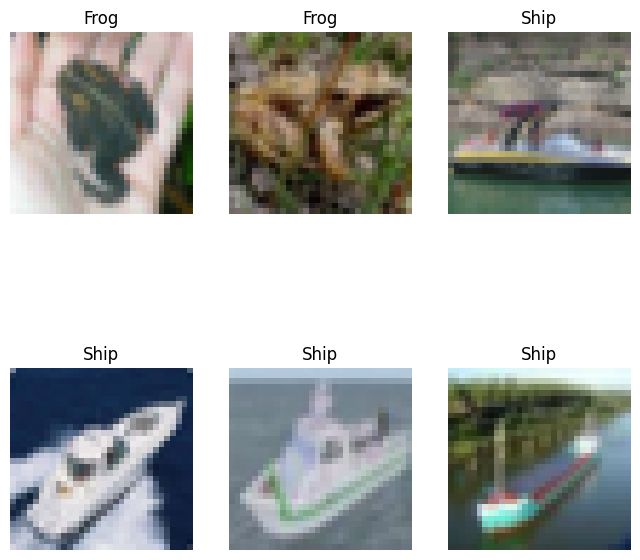

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,394 (1.92 MB)

 Trainable params: 504,330 (1.92 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 131ms/step - accuracy: 0.4545 - loss: 1.5323 - val_accuracy: 0.4597 - val_loss: 1.5036
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 134ms/step - accuracy: 0.5903 - loss: 1.1776 - val_accuracy: 0.6123 - val_loss: 1.1101
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 147s 143ms/step - accuracy: 0.6495 - loss: 1.0209 - val_accuracy: 0.6161 - val_loss: 1.1119
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 135ms/step - accuracy: 0.6841 - loss: 0.9229 - val_accuracy: 0.6233 - val_loss: 1.0860
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 143s 136ms/step - accuracy: 0.7096 - loss: 0.8517 - val_accuracy: 0.4877 - val_loss: 1.9553
Epoch 6/8
526/625 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.7364 - loss: 0.7736

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Flatten,
    Dropout,
    BatchNormalization
)

# Load CIFAR-10 Dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# Normalize Pixel Values
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# Category Names
categories = [
    "Plane",
    "Car",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# Display Random Images
plt.figure(figsize=(8,8))

for index in range(6):

    plt.subplot(2,3,index + 1)

    random_image = np.random.randint(0, len(train_images))

    plt.imshow(train_images[random_image])

    plt.title(
        categories[
            train_labels[random_image][0]
        ]
    )

    plt.axis("off")

plt.show()

# Create CNN Architecture
cnn_model = Sequential()

# Convolution Block 1
cnn_model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    padding='same',
    activation='relu',
    input_shape=(32,32,3)
))

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 2
cnn_model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Block 3
cnn_model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu'
))

cnn_model.add(Dropout(0.25))

# Flatten Layer
cnn_model.add(Flatten())

# Fully Connected Layers
cnn_model.add(Dense(
    128,
    activation='relu'
))

cnn_model.add(Dropout(0.4))

# Output Layer
cnn_model.add(Dense(
    10,
    activation='softmax'
))

# Display Model Summary
cnn_model.summary()

# Compile CNN Model
cnn_model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
training_history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=8,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate Model
loss_value, accuracy_value = cnn_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print("\nCNN Test Accuracy :", accuracy_value)

# Plot Accuracy Graph
plt.figure(figsize=(7,5))

plt.plot(
    training_history.history['accuracy']
)

plt.plot(
    training_history.history['val_accuracy']
)

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

Conclusion

Successfully implemented Convolutional Neural Network using Keras and TensorFlow for image classification on the CIFAR-10 dataset.